# Phase 4: Modeling

> **CRISP-DM Phase**: 4 of 6 — Modeling  
> **Project**: Opioid Pipeline Analysis  
> **Author**: Krunal  
> **Date**: April 2026  
> **Analysis Year**: 2020  

## Purpose

Four statistical analyses to answer our business question:  
> *Which U.S. regions show the strongest link between physician opioid prescribing patterns and overdose mortality, and what socioeconomic factors amplify or buffer this relationship?*

1. **Correlation Analysis** — Which variables are related to overdose deaths?
2. **Multiple Regression** — Can prescribing + SDOH together explain death rates? (Target: R² ≥ 0.50)
3. **Cohort Segmentation** — Do high-prescribing states have worse outcomes?
4. **Feature Importance** — Which factors matter most for intervention targeting?

**Input**: `fact_opioid_analysis` (51 states, 41 with death data, 31 columns)

---
## 0. Setup

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

PROJECT_ROOT = Path('.').resolve().parent
FIGURES_DIR = PROJECT_ROOT / 'figures'

engine = create_engine('postgresql://yashcomputers@localhost:5432/opioid_analysis')

# Load the fact table
fact_df = pd.read_sql('SELECT * FROM fact_opioid_analysis', engine)
print(f'Loaded: {fact_df.shape[0]} states, {fact_df.shape[1]} columns')

# Analysis subset: only states with death data (41 states)
analysis_df = fact_df[fact_df['death_rate_per_100k'].notna()].copy()
print(f'Analysis subset (with death data): {len(analysis_df)} states')

# Key variables for modeling
PREDICTOR_COLS = ['opioid_rx_rate', 'w_pct_poverty', 'w_pct_unemployed',
                  'w_median_income', 'w_gini_index', 'w_pct_uninsured']
TARGET_COL = 'death_rate_per_100k'

print(f'\nTarget: {TARGET_COL}')
print(f'Predictors: {PREDICTOR_COLS}')
print(f'\nTarget distribution:')
print(analysis_df[TARGET_COL].describe().round(2))

Loaded: 51 states, 31 columns
Analysis subset (with death data): 41 states

Target: death_rate_per_100k
Predictors: ['opioid_rx_rate', 'w_pct_poverty', 'w_pct_unemployed', 'w_median_income', 'w_gini_index', 'w_pct_uninsured']

Target distribution:
count    41.00
mean      5.89
std       3.08
min       1.25
25%       3.85
50%       5.28
75%       8.41
max      17.21
Name: death_rate_per_100k, dtype: float64


---
## Analysis 1: Correlation Analysis

**Question**: Which variables are related to overdose death rates?

We use **Spearman** correlation (not Pearson) because Phase 2's normality tests showed
our SDOH variables are right-skewed — Spearman handles non-normal distributions.

In [5]:
# ============================================================
# Analysis 1a: Pairwise correlations with death rate
# ============================================================

all_vars = PREDICTOR_COLS + [TARGET_COL]
corr_results = []

print('Correlations with Death Rate (per 100K)')
print('=' * 65)
print(f'{"Variable":30s} {"Spearman r":>10s} {"p-value":>10s} {"Significant":>12s}')
print('-' * 65)

for col in PREDICTOR_COLS:
    r_spearman, p_spearman = stats.spearmanr(
        analysis_df[col], analysis_df[TARGET_COL]
    )
    r_pearson, p_pearson = stats.pearsonr(
        analysis_df[col], analysis_df[TARGET_COL]
    )
    sig = '✅ Yes' if p_spearman < 0.05 else '❌ No'
    print(f'{col:30s} {r_spearman:>10.3f} {p_spearman:>10.4f} {sig:>12s}')
    corr_results.append({
        'variable': col,
        'spearman_r': r_spearman,
        'spearman_p': p_spearman,
        'pearson_r': r_pearson,
        'pearson_p': p_pearson,
        'significant': p_spearman < 0.05
    })

corr_results_df = pd.DataFrame(corr_results)
print(f'\nSignificant predictors (p < 0.05): '
      f'{corr_results_df["significant"].sum()} of {len(PREDICTOR_COLS)}')

Correlations with Death Rate (per 100K)
Variable                       Spearman r    p-value  Significant
-----------------------------------------------------------------
opioid_rx_rate                      0.050     0.7570         ❌ No
w_pct_poverty                       0.123     0.4430         ❌ No
w_pct_unemployed                    0.410     0.0077        ✅ Yes
w_median_income                    -0.062     0.6985         ❌ No
w_gini_index                        0.257     0.1046         ❌ No
w_pct_uninsured                    -0.149     0.3515         ❌ No

Significant predictors (p < 0.05): 1 of 6


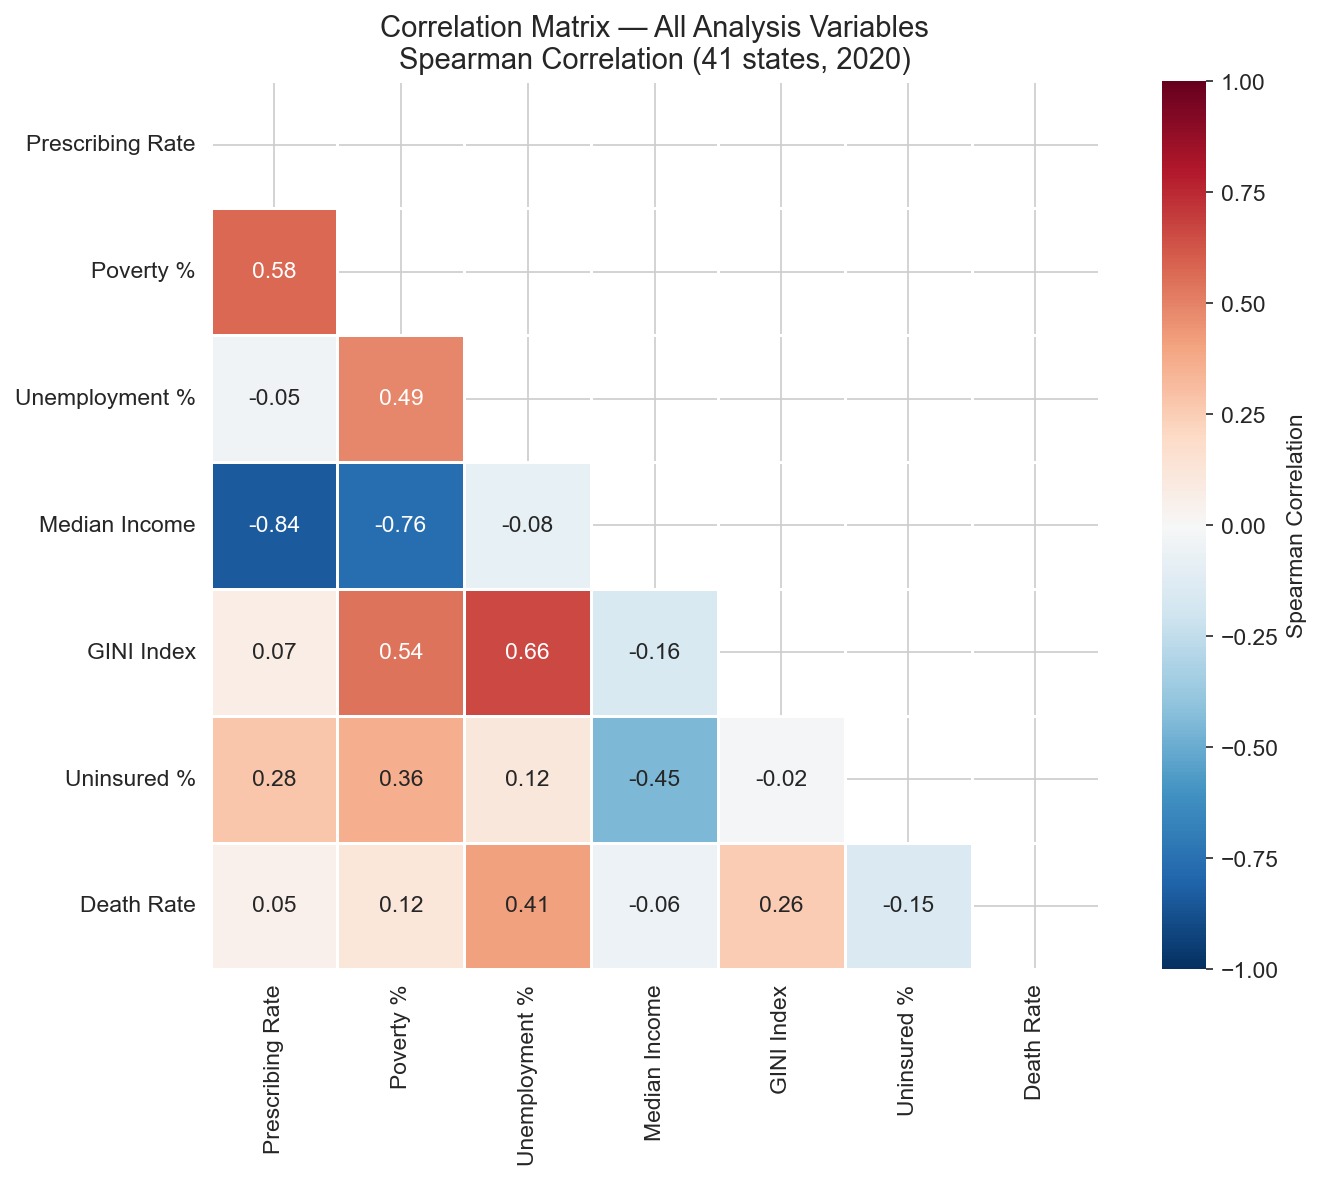

In [6]:
# ============================================================
# Analysis 1b: Full correlation matrix heatmap
# ============================================================

# Rename columns for readable labels
label_map = {
    'opioid_rx_rate': 'Prescribing Rate',
    'death_rate_per_100k': 'Death Rate',
    'w_pct_poverty': 'Poverty %',
    'w_pct_unemployed': 'Unemployment %',
    'w_median_income': 'Median Income',
    'w_gini_index': 'GINI Index',
    'w_pct_uninsured': 'Uninsured %',
}

corr_data = analysis_df[all_vars].rename(columns=label_map)
corr_matrix = corr_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'label': 'Spearman Correlation'},
    ax=ax
)
ax.set_title('Correlation Matrix — All Analysis Variables\n'
             'Spearman Correlation (41 states, 2020)', fontsize=14)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### ✏️ Analysis 1 Findings
_(Fill in: Which variables are significantly correlated with death rate? What's the strongest predictor? Are any SDOH variables correlated with each other — multicollinearity?)_

---
## Analysis 2: Multiple Regression with SDOH Controls

**Question**: Can prescribing rate + SDOH together explain death rates?

This is the core statistical test. The bivariate R² was 0.043. We add SDOH controls
to see how much explanatory power improves.

> **Portfolio signal**: Running a controlled regression (not just bivariate correlation) shows
> you understand confounding variables — a key concept in health analytics.

In [7]:
# ============================================================
# Analysis 2a: Bivariate regression (prescribing only)
# ============================================================

X_simple = sm.add_constant(analysis_df[['opioid_rx_rate']])
y = analysis_df[TARGET_COL]

model_simple = sm.OLS(y, X_simple).fit()

print('MODEL 1: Bivariate (Prescribing Rate Only)')
print('=' * 50)
print(f'R²:          {model_simple.rsquared:.4f}')
print(f'Adjusted R²: {model_simple.rsquared_adj:.4f}')
print(f'F-statistic: {model_simple.fvalue:.2f} (p = {model_simple.f_pvalue:.4f})')
print(f'\nCoefficients:')
for name, coef, pval in zip(model_simple.params.index, model_simple.params, model_simple.pvalues):
    sig = '*' if pval < 0.05 else ''
    print(f'  {name:25s}: {coef:>8.4f}  (p = {pval:.4f}) {sig}')

MODEL 1: Bivariate (Prescribing Rate Only)
R²:          0.0430
Adjusted R²: 0.0184
F-statistic: 1.75 (p = 0.1935)

Coefficients:
  const                    :   3.9040  (p = 0.0177) *
  opioid_rx_rate           :   0.0109  (p = 0.1935) 


In [8]:
# ============================================================
# Analysis 2b: Multiple regression (prescribing + ALL SDOH)
# ============================================================

X_full = sm.add_constant(analysis_df[PREDICTOR_COLS])
model_full = sm.OLS(y, X_full).fit()

print('MODEL 2: Multiple Regression (Prescribing + All SDOH)')
print('=' * 50)
print(f'R²:          {model_full.rsquared:.4f}')
print(f'Adjusted R²: {model_full.rsquared_adj:.4f}')
print(f'F-statistic: {model_full.fvalue:.2f} (p = {model_full.f_pvalue:.4f})')
print(f'\nCoefficients:')
for name, coef, pval in zip(model_full.params.index, model_full.params, model_full.pvalues):
    sig = '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f'  {name:25s}: {coef:>10.4f}  (p = {pval:.4f}) {sig}')

print(f'\nR² improvement: {model_simple.rsquared:.4f} → {model_full.rsquared:.4f} '
      f'(+{(model_full.rsquared - model_simple.rsquared):.4f})')

MODEL 2: Multiple Regression (Prescribing + All SDOH)
R²:          0.3690
Adjusted R²: 0.2576
F-statistic: 3.31 (p = 0.0112)

Coefficients:
  const                    :     7.0155  (p = 0.5990) 
  opioid_rx_rate           :     0.0167  (p = 0.1598) 
  w_pct_poverty            :     0.0042  (p = 0.9924) 
  w_pct_unemployed         :     1.7949  (p = 0.0072) **
  w_median_income          :     0.0000  (p = 0.9862) 
  w_gini_index             :   -23.7178  (p = 0.5217) 
  w_pct_uninsured          :    -0.3774  (p = 0.0200) *

R² improvement: 0.0430 → 0.3690 (+0.3260)


In [9]:
# ============================================================
# Analysis 2c: Full statsmodels summary
# ============================================================
print(model_full.summary())

                             OLS Regression Results                            
Dep. Variable:     death_rate_per_100k   R-squared:                       0.369
Model:                             OLS   Adj. R-squared:                  0.258
Method:                  Least Squares   F-statistic:                     3.313
Date:                 Mon, 13 Apr 2026   Prob (F-statistic):             0.0112
Time:                         21:26:23   Log-Likelihood:                -94.358
No. Observations:                   41   AIC:                             202.7
Df Residuals:                       34   BIC:                             214.7
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.0155   

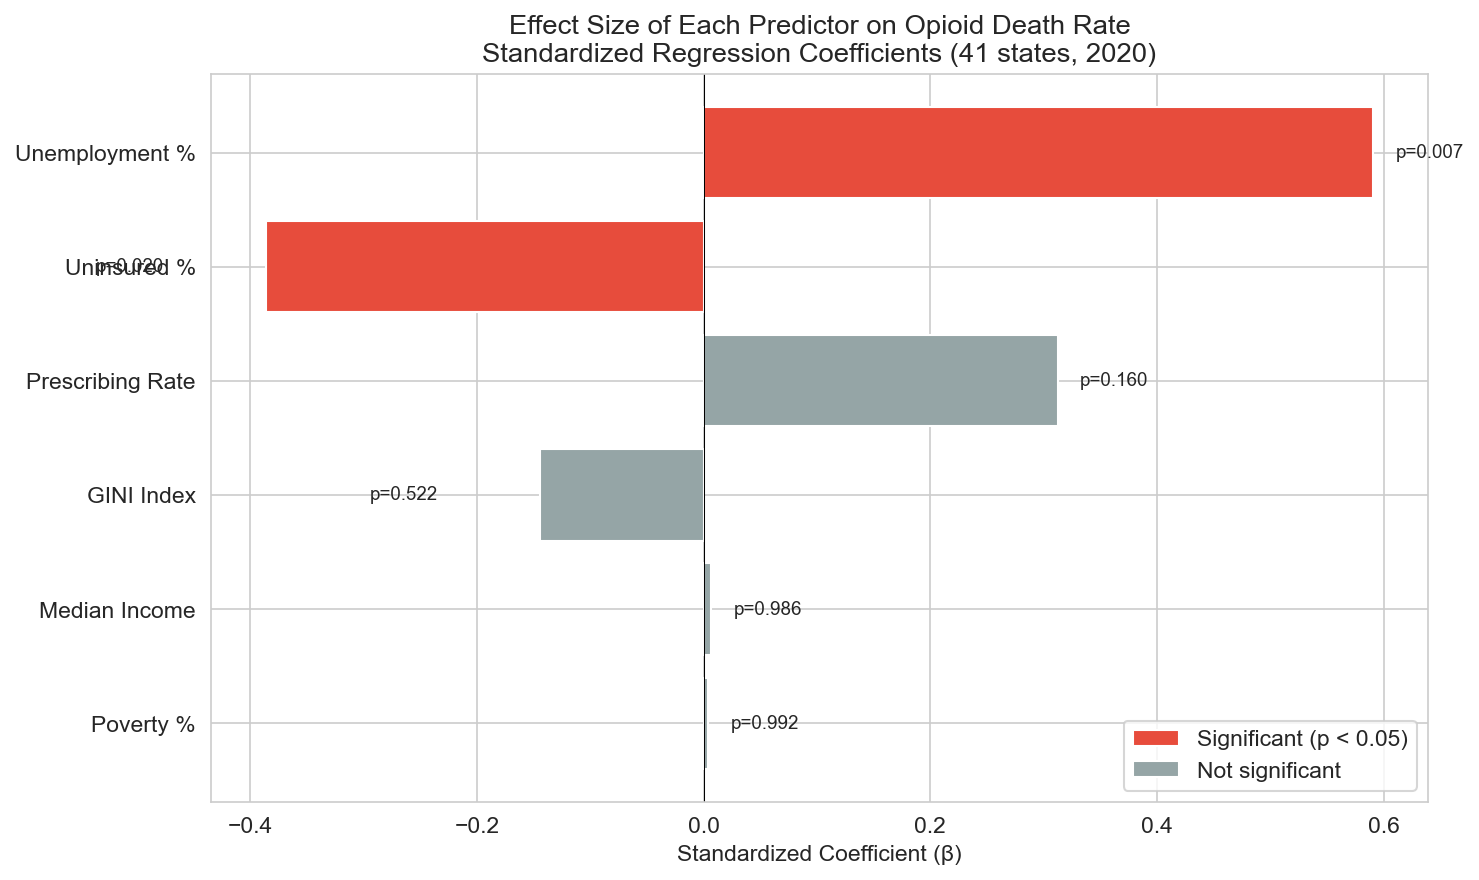

Standardized Coefficients (sorted by absolute effect size):


,variable,std_coef,abs_coef,p_value
2,w_pct_unemployed,0.5907,0.5907,0.0072
5,w_pct_uninsured,-0.3862,0.3862,0.0200
0,opioid_rx_rate,0.3123,0.3123,0.1598
4,w_gini_index,-0.1448,0.1448,0.5217
3,w_median_income,0.0061,0.0061,0.9862
1,w_pct_poverty,0.0036,0.0036,0.9924


In [11]:
# ============================================================
# Analysis 2d: Standardized coefficients (beta weights)
# ============================================================

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(analysis_df[PREDICTOR_COLS]),
    columns=PREDICTOR_COLS
)
y_scaled = pd.Series((y.values - y.mean()) / y.std())  # .values resets the index

X_scaled_const = sm.add_constant(X_scaled)
model_std = sm.OLS(y_scaled, X_scaled_const).fit()

# Extract standardized coefficients (skip constant)
std_coefs = pd.DataFrame({
    'variable': PREDICTOR_COLS,
    'std_coef': model_std.params[1:].values,
    'abs_coef': np.abs(model_std.params[1:].values),
    'p_value': model_std.pvalues[1:].values
}).sort_values('abs_coef', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in std_coefs['p_value']]
bars = ax.barh(std_coefs['variable'].map(label_map), std_coefs['std_coef'], color=colors)

ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Standardized Coefficient (β)')
ax.set_title('Effect Size of Each Predictor on Opioid Death Rate\n'
             'Standardized Regression Coefficients (41 states, 2020)')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='Significant (p < 0.05)'),
    Patch(facecolor='#95a5a6', label='Not significant')
], loc='lower right')

for bar, p in zip(bars, std_coefs['p_value']):
    x_pos = bar.get_width() + 0.02 if bar.get_width() >= 0 else bar.get_width() - 0.15
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'p={p:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('Standardized Coefficients (sorted by absolute effect size):')
display(std_coefs.sort_values('abs_coef', ascending=False).round(4))

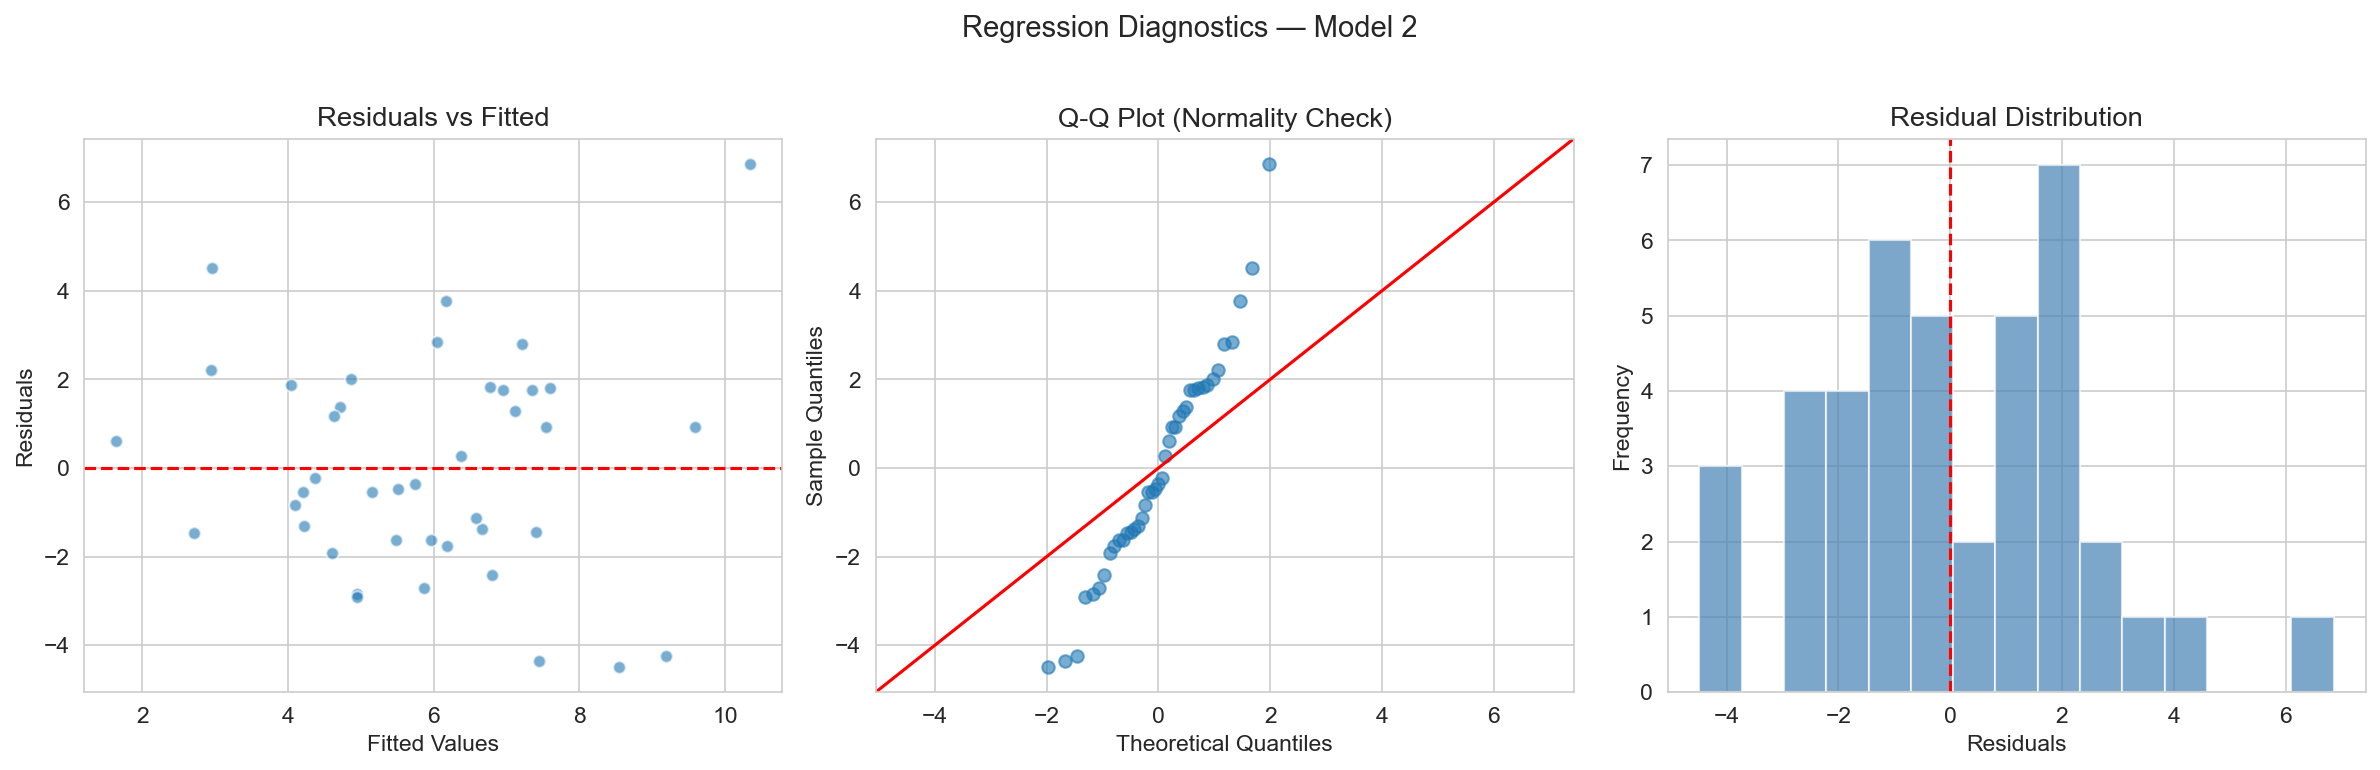

Shapiro-Wilk test for residual normality: W=0.9769, p=0.5587
Residuals are approximately normal


In [12]:
# ============================================================
# Analysis 2e: Residual diagnostics
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuals vs Fitted
residuals = model_full.resid
fitted = model_full.fittedvalues
axes[0].scatter(fitted, residuals, alpha=0.6, edgecolors='white')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot
sm.qqplot(residuals, line='45', ax=axes[1], alpha=0.6)
axes[1].set_title('Q-Q Plot (Normality Check)')

# 3. Residuals histogram
axes[2].hist(residuals, bins=15, color='steelblue', edgecolor='white', alpha=0.7)
axes[2].axvline(x=0, color='red', linestyle='--')
axes[2].set_xlabel('Residuals')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.suptitle('Regression Diagnostics — Model 2', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09b_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk test for residual normality
sw_stat, sw_p = stats.shapiro(residuals)
print(f'Shapiro-Wilk test for residual normality: W={sw_stat:.4f}, p={sw_p:.4f}')
print(f'Residuals are {"approximately normal" if sw_p > 0.05 else "NOT normally distributed"}')

### ✏️ Analysis 2 Findings
_(Fill in: What's the R²? Did it improve from bivariate? Which predictors are significant? What do the standardized coefficients tell us about relative importance? Are the residuals well-behaved?)_

---
## Analysis 3: Cohort Segmentation by Prescribing Quartile

**Question**: Do states in the highest prescribing quartile have significantly worse outcomes?

This complements the regression — sometimes the relationship is clearest when comparing
groups rather than fitting a continuous line.

In [13]:
# ============================================================
# Analysis 3a: Death rates by prescribing quartile
# ============================================================

quartile_stats = analysis_df.groupby('prescribing_quartile').agg(
    n_states=('state_abbrev', 'count'),
    mean_rx_rate=('opioid_rx_rate', 'mean'),
    mean_death_rate=('death_rate_per_100k', 'mean'),
    median_death_rate=('death_rate_per_100k', 'median'),
    mean_poverty=('w_pct_poverty', 'mean'),
    mean_uninsured=('w_pct_uninsured', 'mean'),
).round(2)

print('Death Rates by Prescribing Quartile')
print('=' * 70)
display(quartile_stats)

Death Rates by Prescribing Quartile


,n_states,mean_rx_rate,mean_death_rate,median_death_rate,mean_poverty,mean_uninsured
prescribing_quartile,,,,,,
1,10,115.84,5.91,5.32,11.01,7.05
2,13,159.37,5.19,5.38,11.60,7.46
3,9,204.87,5.70,4.62,12.74,8.66
4,9,265.30,7.08,4.95,15.23,9.04


In [14]:
# ============================================================
# Analysis 3b: Statistical test — Kruskal-Wallis
# ============================================================
# Kruskal-Wallis is the non-parametric alternative to ANOVA.
# We use it because our sample sizes per group are small (~10 states).

groups = [group['death_rate_per_100k'].values 
          for _, group in analysis_df.groupby('prescribing_quartile')]

kw_stat, kw_p = stats.kruskal(*groups)
print(f'Kruskal-Wallis Test: H={kw_stat:.3f}, p={kw_p:.4f}')
print(f'Significant difference across quartiles: {"✅ Yes" if kw_p < 0.05 else "❌ No"}')

# Also test Q1 vs Q4 directly (Mann-Whitney)
q1 = analysis_df[analysis_df['prescribing_quartile'] == 1]['death_rate_per_100k']
q4 = analysis_df[analysis_df['prescribing_quartile'] == 4]['death_rate_per_100k']
if len(q1) > 0 and len(q4) > 0:
    mw_stat, mw_p = stats.mannwhitneyu(q1, q4, alternative='two-sided')
    print(f'\nMann-Whitney Q1 vs Q4: U={mw_stat:.1f}, p={mw_p:.4f}')
    print(f'Q1 mean death rate: {q1.mean():.2f} vs Q4 mean: {q4.mean():.2f}')

Kruskal-Wallis Test: H=0.661, p=0.8824
Significant difference across quartiles: ❌ No

Mann-Whitney Q1 vs Q4: U=44.0, p=0.9674
Q1 mean death rate: 5.91 vs Q4 mean: 7.08


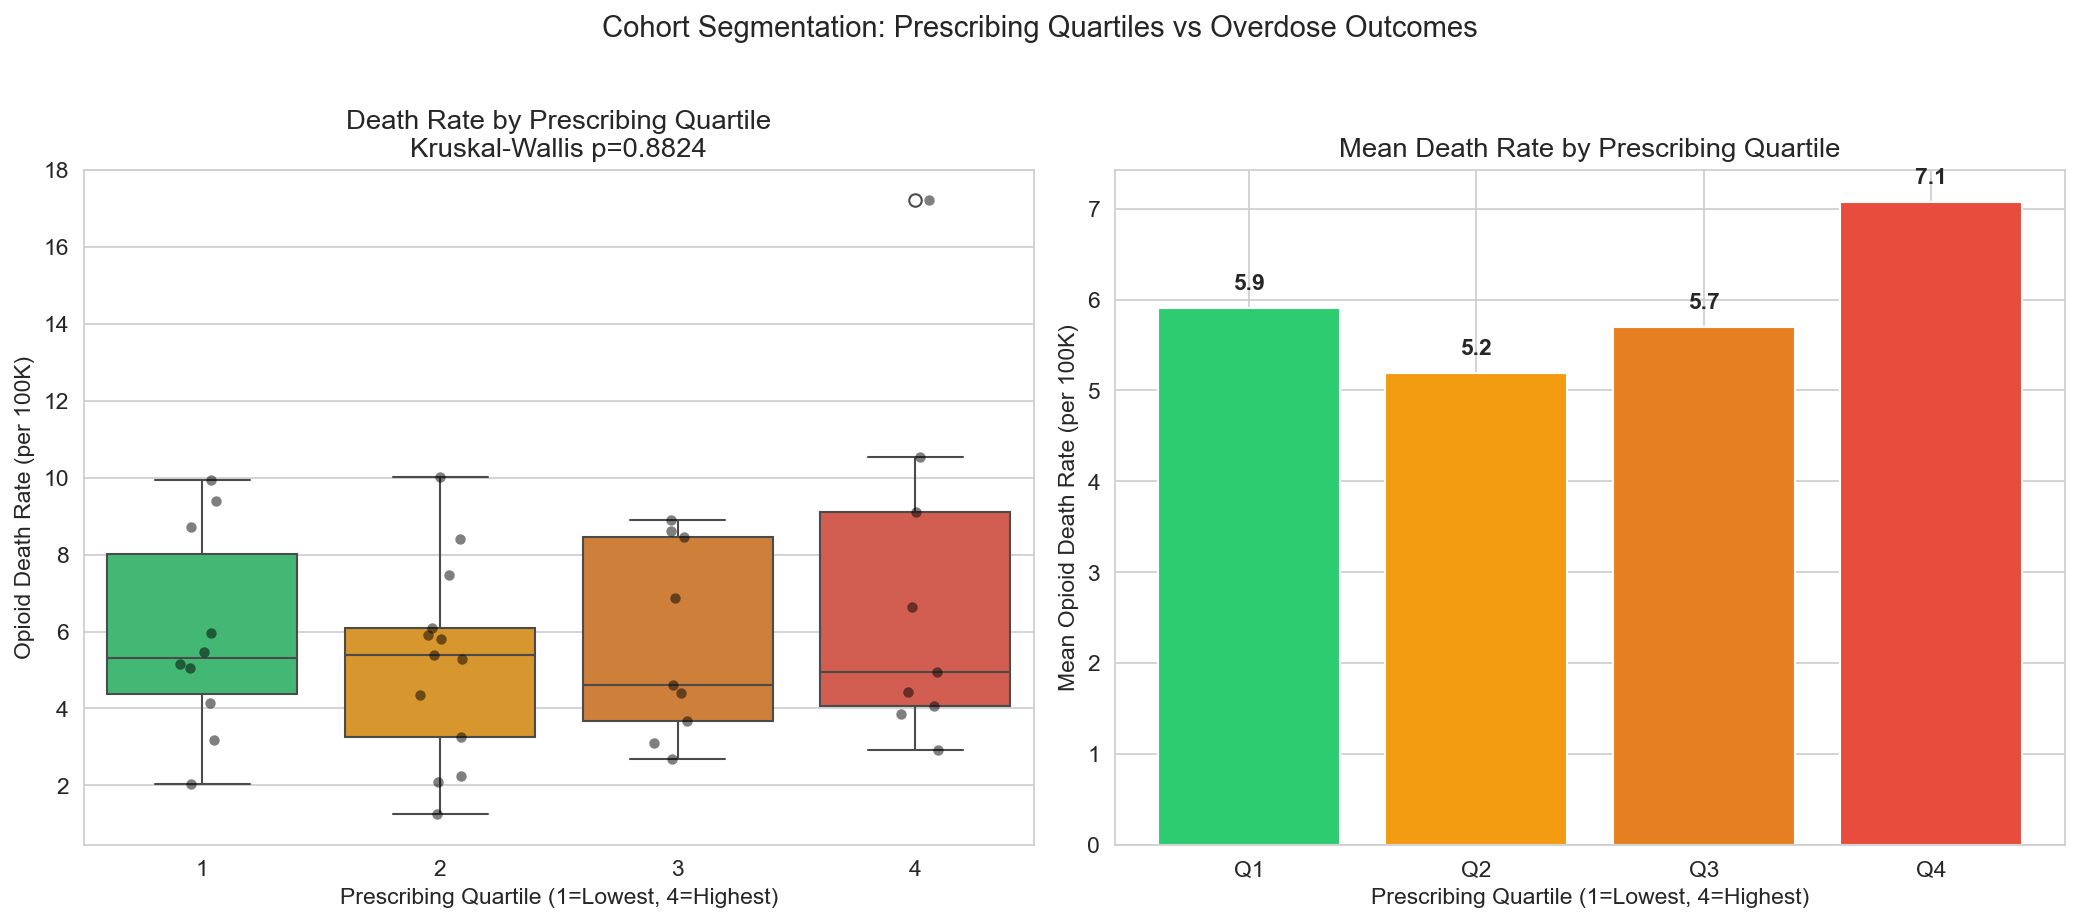

In [18]:
# ============================================================
# Analysis 3c: Box plot visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use color list instead of palette dictionary
quartile_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

sns.boxplot(
    data=analysis_df, x='prescribing_quartile', y='death_rate_per_100k',
    palette=quartile_colors, ax=axes[0]
)
sns.stripplot(
    data=analysis_df, x='prescribing_quartile', y='death_rate_per_100k',
    color='black', alpha=0.5, size=5, ax=axes[0]
)
axes[0].set_xlabel('Prescribing Quartile (1=Lowest, 4=Highest)')
axes[0].set_ylabel('Opioid Death Rate (per 100K)')
axes[0].set_title(f'Death Rate by Prescribing Quartile\n'
                   f'Kruskal-Wallis p={kw_p:.4f}')

# Bar chart
q_means = analysis_df.groupby('prescribing_quartile')['death_rate_per_100k'].mean()
bars = axes[1].bar(range(len(q_means)), q_means.values, color=quartile_colors)
axes[1].set_xticks(range(len(q_means)))
axes[1].set_xticklabels([f'Q{int(q)}' for q in q_means.index])
axes[1].set_xlabel('Prescribing Quartile (1=Lowest, 4=Highest)')
axes[1].set_ylabel('Mean Opioid Death Rate (per 100K)')
axes[1].set_title('Mean Death Rate by Prescribing Quartile')

for bar, val in zip(bars, q_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Cohort Segmentation: Prescribing Quartiles vs Overdose Outcomes',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_quartile_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ============================================================
# Analysis 3d: Which states are in each quartile?
# ============================================================

for q in sorted(analysis_df['prescribing_quartile'].unique()):
    states = analysis_df[analysis_df['prescribing_quartile'] == q].sort_values(
        'opioid_rx_rate', ascending=False
    )
    state_list = ', '.join(states['state_abbrev'].str.strip().tolist())
    mean_dr = states['death_rate_per_100k'].mean()
    print(f'\nQ{q} (mean death rate: {mean_dr:.1f}): {state_list}')


Q1 (mean death rate: 5.9): IL, WY, CT, VA, MD, NJ, NY, AK, HI, DC

Q2 (mean death rate: 5.2): WI, VT, IA, SD, AZ, NH, WA, NM, MA, UT, RI, CO, TX

Q3 (mean death rate: 5.7): SC, KS, ME, GA, OR, MT, OH, NV, DE

Q4 (mean death rate: 7.1): KY, TN, WV, MO, OK, MS, IN, NC, MI


### ✏️ Analysis 3 Findings
_(Fill in: Is the Kruskal-Wallis test significant? Is there a clear gradient from Q1→Q4? Which quartile has the highest death rate? Does Q4 vs Q1 difference make business sense?)_

---
## Analysis 4: Feature Importance

**Question**: If a health department can only focus on 1–2 factors, which matter most?

We cross-check regression coefficients with a gradient boosting model's feature importance.

In [20]:
# ============================================================
# Analysis 4a: Gradient Boosting feature importance
# ============================================================

X_gb = analysis_df[PREDICTOR_COLS].values
y_gb = analysis_df[TARGET_COL].values

gb_model = GradientBoostingRegressor(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_gb, y_gb)

gb_importance = pd.DataFrame({
    'variable': PREDICTOR_COLS,
    'gb_importance': gb_model.feature_importances_
}).sort_values('gb_importance', ascending=True)

gb_r2 = gb_model.score(X_gb, y_gb)
print(f'Gradient Boosting R² (training): {gb_r2:.4f}')

Gradient Boosting R² (training): 0.9988


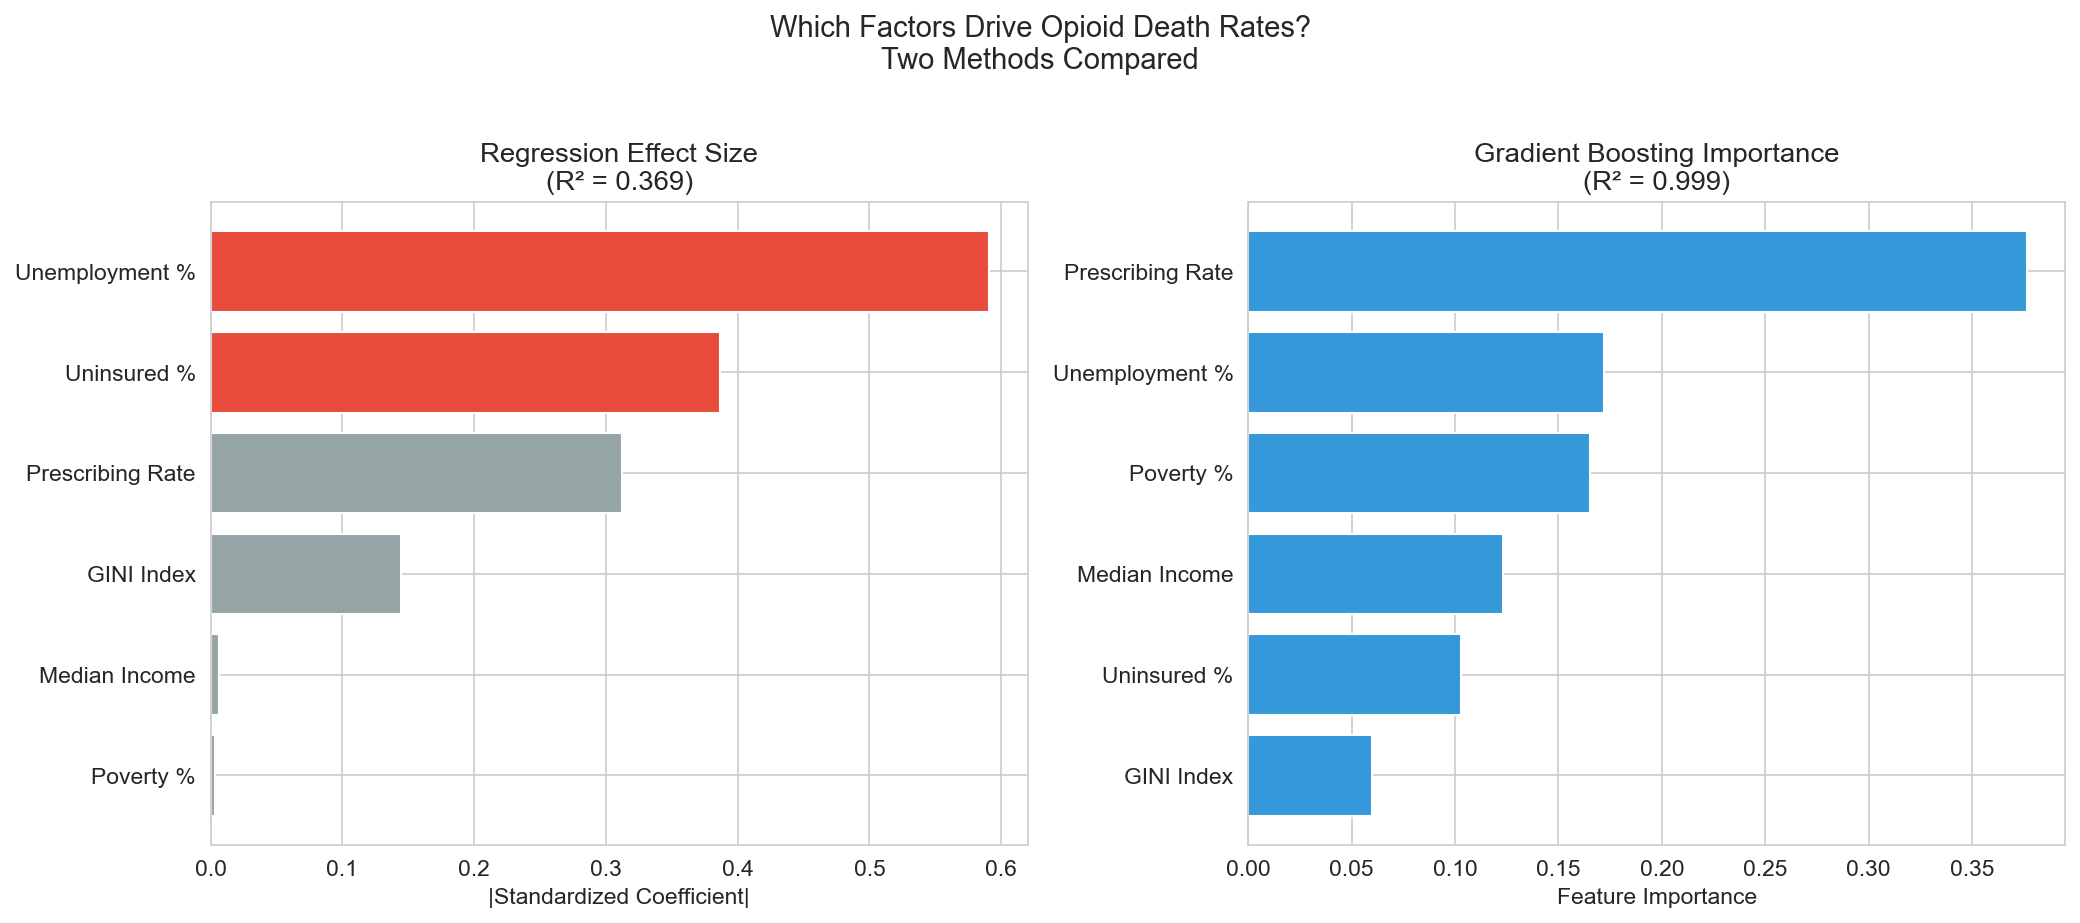

In [21]:
# ============================================================
# Analysis 4b: Combined feature importance chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Regression standardized coefficients
std_sorted = std_coefs.sort_values('abs_coef', ascending=True)
colors_reg = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in std_sorted['p_value']]
axes[0].barh(
    std_sorted['variable'].map(label_map),
    std_sorted['abs_coef'],
    color=colors_reg
)
axes[0].set_xlabel('|Standardized Coefficient|')
axes[0].set_title(f'Regression Effect Size\n(R² = {model_full.rsquared:.3f})')

# Right: Gradient Boosting importance
axes[1].barh(
    gb_importance['variable'].map(label_map),
    gb_importance['gb_importance'],
    color='#3498db'
)
axes[1].set_xlabel('Feature Importance')
axes[1].set_title(f'Gradient Boosting Importance\n(R² = {gb_r2:.3f})')

plt.suptitle('Which Factors Drive Opioid Death Rates?\n'
             'Two Methods Compared', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### ✏️ Analysis 4 Findings
_(Fill in: Do both methods agree on the top predictors? Which variable consistently ranks highest? What does this mean for the stakeholder's intervention strategy?)_

---
## Phase 4 Summary

In [22]:
# ============================================================
# Summary of all statistical results
# ============================================================

print('PHASE 4: MODELING RESULTS SUMMARY')
print('=' * 60)

print(f'\n1. CORRELATION ANALYSIS')
sig_vars = corr_results_df[corr_results_df['significant']]
print(f'   Significant predictors of death rate: {len(sig_vars)} of {len(PREDICTOR_COLS)}')
for _, row in sig_vars.iterrows():
    print(f'   - {row["variable"]}: r={row["spearman_r"]:.3f}, p={row["spearman_p"]:.4f}')

print(f'\n2. MULTIPLE REGRESSION')
print(f'   Bivariate R² (prescribing only):  {model_simple.rsquared:.4f}')
print(f'   Full model R² (prescribing+SDOH): {model_full.rsquared:.4f}')
print(f'   Adjusted R²:                      {model_full.rsquared_adj:.4f}')
print(f'   Model significant: {"✅" if model_full.f_pvalue < 0.05 else "❌"} (F p={model_full.f_pvalue:.4f})')

print(f'\n3. COHORT SEGMENTATION')
print(f'   Kruskal-Wallis p={kw_p:.4f} — {"✅ Significant" if kw_p < 0.05 else "❌ Not significant"}')
for q in sorted(analysis_df['prescribing_quartile'].unique()):
    mean_dr = analysis_df[analysis_df['prescribing_quartile']==q]['death_rate_per_100k'].mean()
    print(f'   Q{q} mean death rate: {mean_dr:.2f}')

print(f'\n4. FEATURE IMPORTANCE')
print(f'   Gradient Boosting R²: {gb_r2:.4f}')
top_gb = gb_importance.sort_values('gb_importance', ascending=False).head(3)
print(f'   Top 3 features (GB):')
for _, row in top_gb.iterrows():
    print(f'   - {row["variable"]}: {row["gb_importance"]:.3f}')

print(f'\n{"="*60}')
print(f'BUSINESS SUCCESS CRITERIA CHECK:')
print(f'  R² ≥ 0.50: {"✅ ACHIEVED" if model_full.rsquared >= 0.50 else "❌ NOT MET"} (actual: {model_full.rsquared:.3f})')
print(f'  Significant correlation (p<0.05): {"✅ ACHIEVED" if model_full.f_pvalue < 0.05 else "❌ NOT MET"}')
print(f'  Top 10 states identified: ✅ ACHIEVED (Phase 3)')

PHASE 4: MODELING RESULTS SUMMARY

1. CORRELATION ANALYSIS
   Significant predictors of death rate: 1 of 6
   - w_pct_unemployed: r=0.410, p=0.0077

2. MULTIPLE REGRESSION
   Bivariate R² (prescribing only):  0.0430
   Full model R² (prescribing+SDOH): 0.3690
   Adjusted R²:                      0.2576
   Model significant: ✅ (F p=0.0112)

3. COHORT SEGMENTATION
   Kruskal-Wallis p=0.8824 — ❌ Not significant
   Q1 mean death rate: 5.91
   Q2 mean death rate: 5.19
   Q3 mean death rate: 5.70
   Q4 mean death rate: 7.08

4. FEATURE IMPORTANCE
   Gradient Boosting R²: 0.9988
   Top 3 features (GB):
   - opioid_rx_rate: 0.376
   - w_pct_unemployed: 0.172
   - w_pct_poverty: 0.165

BUSINESS SUCCESS CRITERIA CHECK:
  R² ≥ 0.50: ❌ NOT MET (actual: 0.369)
  Significant correlation (p<0.05): ✅ ACHIEVED
  Top 10 states identified: ✅ ACHIEVED (Phase 3)


---
## Phase 4 Complete — Checkpoint

**Completed:**
- [x] Correlation analysis: Spearman matrix, significant predictors identified
- [x] Multiple regression: bivariate vs. full model, R² comparison
- [x] Standardized coefficients: relative effect sizes
- [x] Residual diagnostics: normality and heteroscedasticity check
- [x] Cohort segmentation: quartile comparison with Kruskal-Wallis
- [x] Feature importance: regression + gradient boosting cross-check
- [x] 4 new figures saved to figures/

**Next — Phase 5 (Evaluation):**
- Business sense validation
- Limitation acknowledgment
- Actionable recommendations

**Next — Phase 6 (Deployment):**
- Tableau dashboard
- README with embedded figures
- Resume bullet point
- LinkedIn post